In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0, "../../run")
from const import REPO_PATH
from inference_config import INFERENCE_CONFIG

sys.path.insert(1, f"{REPO_PATH}")
from src.feature.feature_encoders import TeamEncoder, TeamLagFeatureGenerator, PreviousSeasonTeamAverager, TeamRestDaysCalculator, TeamLagTargetFeature
import joblib
import os

In [2]:
seasons=sorted(INFERENCE_CONFIG['seasons'])
data_dfs=[pd.read_csv(f"{INFERENCE_CONFIG['processed_path']}/{season}/all_data_df.csv") for season in seasons]
target_dfs=[pd.read_csv(f"{INFERENCE_CONFIG['processed_path']}/{season}/all_target_df.csv") for season in seasons]

## Generate feature vector for a single match using all feature classes

This function takes a list of season DataFrames, a home/away team, a date, and a list of target DataFrames, and generates the feature vector using the fitted encoder and all feature classes in feature_encoders.py. It uses the existing encoder and does not retrain any feature class.

In [3]:
def generate_features_for_match(
    season_dfs,
    target_dfs,
    home_teams,
    away_teams,
    match_dates,
    encoder_path,
    lookback=5,
    decay_factor=1.0,
    home_col='home',
    away_col='away',
    date_col='date'
):
    """
    Generate feature vectors for multiple matches using all feature classes.

    Args:
        season_dfs (list of pd.DataFrame): List of season DataFrames (chronological order).
        target_dfs (list of pd.DataFrame): List of target DataFrames (chronological order).
        home_teams (list): List of home team names.
        away_teams (list): List of away team names.
        match_dates (list): List of match dates (str or pd.Timestamp).
        encoder_path (str): Path to the fitted TeamEncoder.
        lookback (int): Lookback for lag features.
        decay_factor (float): Decay for previous season features.
        home_col, away_col, date_col: Column names.

    Returns:
        pd.DataFrame: DataFrame with all features for the matches.
    """
    # Convert all match_dates to pd.Timestamp
    match_dates = [pd.to_datetime(d) for d in match_dates]
    n_matches = len(home_teams)
    assert len(away_teams) == n_matches and len(match_dates) == n_matches, "Input lists must have the same length"

    # --- Filter season_dfs and target_dfs for relevant teams ---
    relevant_teams = set(home_teams) | set(away_teams)
    filtered_season_dfs = []
    filtered_target_dfs = []
    for season_df, target_df in zip(season_dfs, target_dfs):
        mask = season_df[home_col].isin(relevant_teams) | season_df[away_col].isin(relevant_teams)
        filtered_season_dfs.append(season_df[mask].reset_index(drop=True))
        filtered_target_dfs.append(target_df[mask].reset_index(drop=True))
    season_dfs = filtered_season_dfs
    target_dfs = filtered_target_dfs

    # --- Team Encoding ---
    encoder = TeamEncoder.load(encoder_path)
    team_encoding = encoder.encoder.transform(list(zip(home_teams, away_teams)))
    team_encoding_cols = encoder.encoder.get_feature_names_out(['encoded_home', 'encoded_away'])
    team_encoding_df = pd.DataFrame(team_encoding, columns=team_encoding_cols)
    team_encoding_df[home_col] = home_teams
    team_encoding_df[away_col] = away_teams
    team_encoding_df[date_col] = match_dates

    # --- Lag Features ---
    lag_generator = TeamLagFeatureGenerator(lookback=lookback, date_col=date_col, home_col=home_col, away_col=away_col)
    lag_features_df = lag_generator.transform(season_dfs)
    lag_rows = []
    for h, a, d in zip(home_teams, away_teams, match_dates):
        row = lag_features_df[
            (lag_features_df[home_col] == h) &
            (lag_features_df[away_col] == a) &
            (lag_features_df[date_col] <= d)
        ].sort_values(date_col, ascending=False).head(1)
        if row.empty:
            row = pd.DataFrame(columns=lag_features_df.columns)
        row = row.copy()
        row[home_col] = h
        row[away_col] = a
        row[date_col] = d
        lag_rows.append(row)
    lag_rows_df = pd.concat(lag_rows, ignore_index=True) if lag_rows else pd.DataFrame()

    # --- Previous Season Features ---
    prev_season_generator = PreviousSeasonTeamAverager(decay_factor=decay_factor, date_col=date_col, home_col=home_col, away_col=away_col)
    prev_season_features_df = prev_season_generator.transform(season_dfs)
    prev_rows = []
    for h, a, d in zip(home_teams, away_teams, match_dates):
        row = prev_season_features_df[
            (prev_season_features_df[home_col] == h) &
            (prev_season_features_df[away_col] == a) &
            (prev_season_features_df[date_col] <= d)
        ].sort_values(date_col, ascending=False).head(1)
        if row.empty:
            row = pd.DataFrame(columns=prev_season_features_df.columns)
        row = row.copy()
        row[home_col] = h
        row[away_col] = a
        row[date_col] = d
        prev_rows.append(row)
    prev_rows_df = pd.concat(prev_rows, ignore_index=True) if prev_rows else pd.DataFrame()

    # --- Rest Days Features ---
    rest_days_generator = TeamRestDaysCalculator(home_col=home_col, away_col=away_col, date_col=date_col)
    rest_days_features_df = rest_days_generator.transform(season_dfs)
    rest_rows = []
    for h, a, d in zip(home_teams, away_teams, match_dates):
        row = rest_days_features_df[
            (rest_days_features_df[home_col] == h) &
            (rest_days_features_df[away_col] == a) &
            (rest_days_features_df[date_col] <= d)
        ].sort_values(date_col, ascending=False).head(1)
        if row.empty:
            row = pd.DataFrame(columns=rest_days_features_df.columns)
        row = row.copy()
        row[home_col] = h
        row[away_col] = a
        row[date_col] = d
        rest_rows.append(row)
    rest_rows_df = pd.concat(rest_rows, ignore_index=True) if rest_rows else pd.DataFrame()

    # --- Lag Target Features ---
    lag_target_generator = TeamLagTargetFeature(lookback=lookback, date_col=date_col, home_col=home_col, away_col=away_col)
    lag_target_features_df = lag_target_generator.transform(season_dfs, target_dfs)
    lag_target_rows = []
    for h, a, d in zip(home_teams, away_teams, match_dates):
        row = lag_target_features_df[
            (lag_target_features_df[home_col] == h) &
            (lag_target_features_df[away_col] == a) &
            (lag_target_features_df[date_col] <= d)
        ].sort_values(date_col, ascending=False).head(1)
        if row.empty:
            row = pd.DataFrame(columns=lag_target_features_df.columns)
        row = row.copy()
        row[home_col] = h
        row[away_col] = a
        row[date_col] = d
        lag_target_rows.append(row)
    lag_target_rows_df = pd.concat(lag_target_rows, ignore_index=True) if lag_target_rows else pd.DataFrame()

    # --- Merge all features ---
    merged = team_encoding_df.merge(
        lag_rows_df, on=[home_col, away_col, date_col], how='left', suffixes=('', '_lag')
    ).merge(
        prev_rows_df, on=[home_col, away_col, date_col], how='left', suffixes=('', '_prev')
    ).merge(
        rest_rows_df, on=[home_col, away_col, date_col], how='left', suffixes=('', '_rest')
    ).merge(
        lag_target_rows_df, on=[home_col, away_col, date_col], how='left', suffixes=('', '_lagtarget')
    )

    merged = merged.fillna(-1)
    return merged

In [4]:
feature_vector=generate_features_for_match(
    season_dfs=data_dfs,
    target_dfs=target_dfs,
    home_teams=['Chelsea'],
    away_teams=['Bournemouth'],
    match_dates=['2025-01-14'],
    encoder_path=f"{INFERENCE_CONFIG['data_processor_path']}/team_encoder.pkl"
)

/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [5]:
feature_vector['encoded_home_Chelsea'], feature_vector['encoded_away_Bournemouth']

(0    1.0
 Name: encoded_home_Chelsea, dtype: float64,
 0    1.0
 Name: encoded_away_Bournemouth, dtype: float64)

In [6]:
feature_vector

,encoded_home_Arsenal,encoded_home_Bournemouth,encoded_home_Brighton,encoded_home_Burnley,encoded_home_Chelsea,encoded_home_Crystal Palace,encoded_home_Everton,encoded_home_Huddersfield,encoded_home_Leicester City,encoded_home_Liverpool,...,away_lag_5_home_goals,away_lag_5_away_goals,away_lag_5_home_corners,away_lag_5_away_corners,away_lag_5_home_cards,away_lag_5_away_cards,away_lag_5_home_shots,away_lag_5_away_shots,away_lag_5_home_sots,away_lag_5_away_sots
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,11.0,6.0,0.0,2.0,29.0,15.0,9.0,2.0


## Load trained model and run inference on feature vector

In [ ]:
def load_models_and_predict(model_dir, target_ranges, feature_df):
    """
    Loads trained models for each target in target_ranges from the given directory,
    and predicts probabilities on the given feature_df for each target.
    Returns a dict: {target_name: {class_value: probability array}}
    The output keys for each target are the class values in the range.
    """
    results = {}
    for target, (min_val, max_val) in target_ranges.items():
        # Find model file for this target
        model_files = [f for f in os.listdir(model_dir) if target in f and f.endswith('.joblib')]
        if not model_files:
            print(f"No model file found for target: {target}")
            continue
        model_path = os.path.join(model_dir, model_files[0])
        model = joblib.load(model_path)
        # Remove key columns if present
        X = feature_df.copy()
        for col in ['home', 'away', 'date']:
            if col in X.columns:
                X = X.drop(columns=[col])
        print(len(model.model.feature_names_in_), "features in model")
        y_proba = model.predict_proba(X)
        # Build class value mapping
        class_labels = list(range(min_val, max_val + 1))
        target_dict = {c: np.zeros(len(X)) for c in class_labels}
        for idx, cls in enumerate(model.model.classes_):
            if cls in target_dict:
                target_dict[cls] = y_proba[:, idx]
        results[target] = target_dict
    return results

In [24]:
feature_df = pd.read_csv(f'{REPO_PATH}/data/features/premier_league/all_combined_features_2017-24.csv')

In [25]:
feature_df.columns

Index(['home', 'away', 'date', 'encoded_home_Arsenal',
       'encoded_home_Bournemouth', 'encoded_home_Brighton',
       'encoded_home_Burnley', 'encoded_home_Chelsea',
       'encoded_home_Crystal Palace', 'encoded_home_Everton',
       ...
       'away_lag_5_home_goals', 'away_lag_5_away_goals',
       'away_lag_5_home_corners', 'away_lag_5_away_corners',
       'away_lag_5_home_cards', 'away_lag_5_away_cards',
       'away_lag_5_home_shots', 'away_lag_5_away_shots',
       'away_lag_5_home_sots', 'away_lag_5_away_sots'],
      dtype='object', length=2729)

In [32]:
feature_vector[feature_df.columns]['home_lag_1_home_sots']

0    6.0
Name: home_lag_1_home_sots, dtype: float64

In [36]:
predictions = load_models_and_predict(INFERENCE_CONFIG['save_model_path'], INFERENCE_CONFIG['target_ranges'], feature_vector[feature_df.columns])

Processing target: home_goals with range 0 to 5
2726 features in model
Processing target: away_goals with range 0 to 6
2726 features in model
Processing target: home_corners with range 3 to 7
2726 features in model
Processing target: away_corners with range 3 to 7
2726 features in model
Processing target: home_cards with range 0 to 7
2726 features in model
Processing target: away_cards with range 0 to 7
2726 features in model
Processing target: home_shots with range 5 to 20
2726 features in model
Processing target: away_shots with range 5 to 20
2726 features in model
Processing target: home_sots with range 1 to 10
2726 features in model
Processing target: away_sots with range 1 to 10
2726 features in model


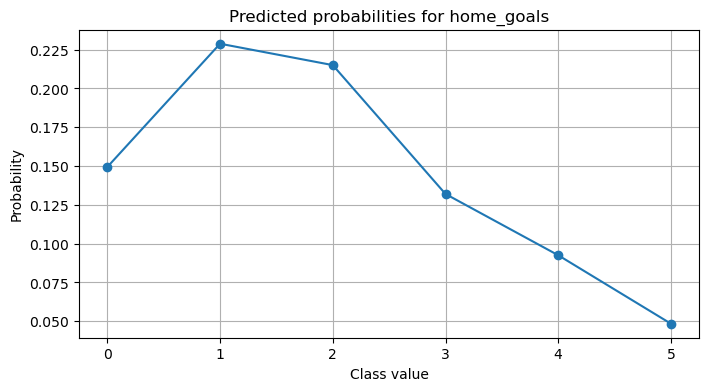

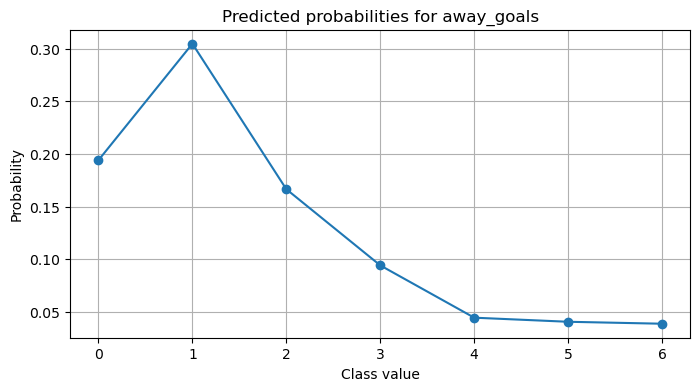

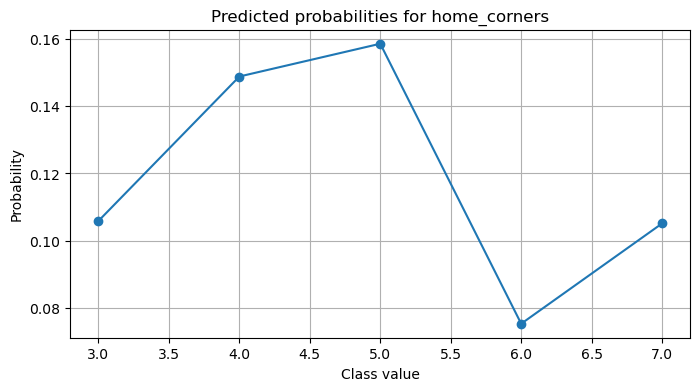

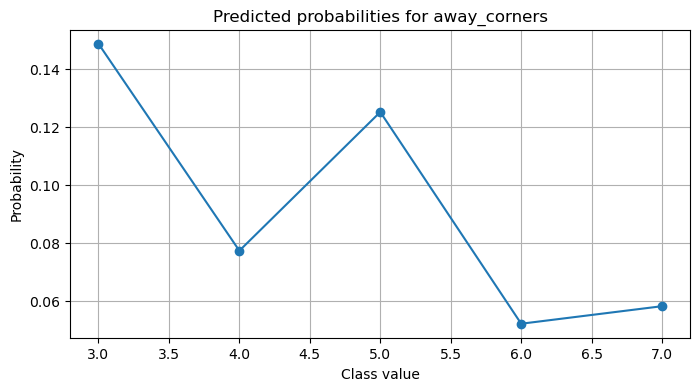

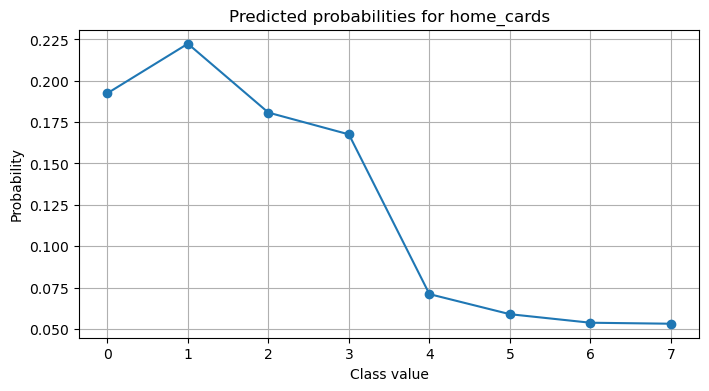

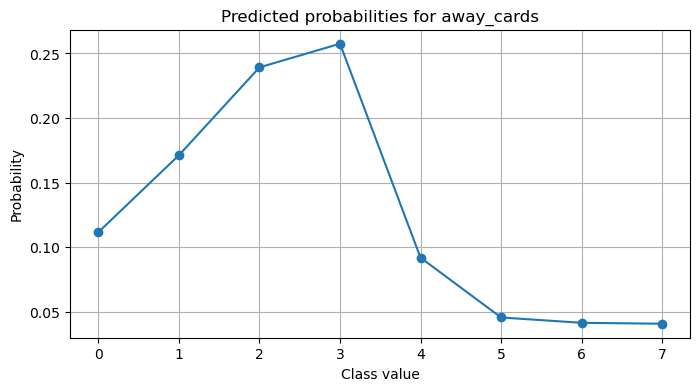

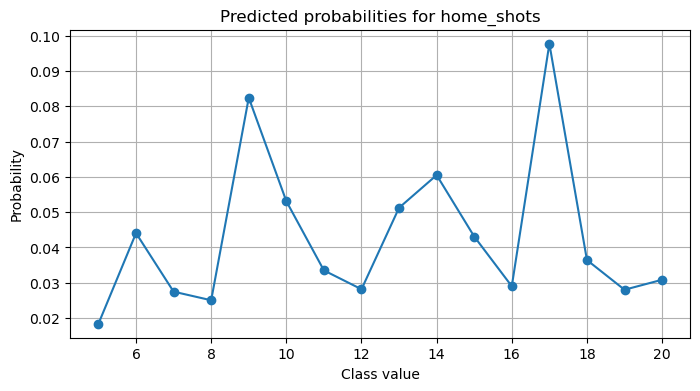

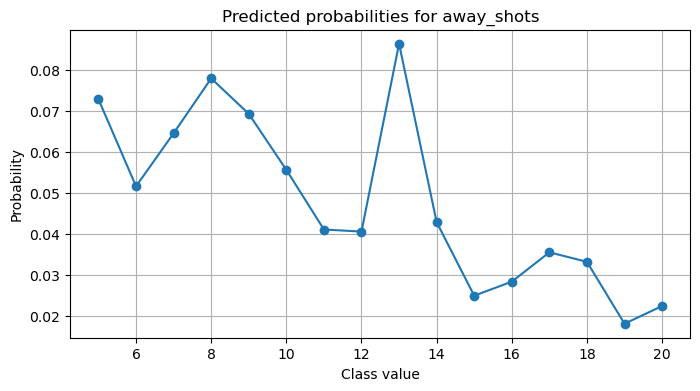

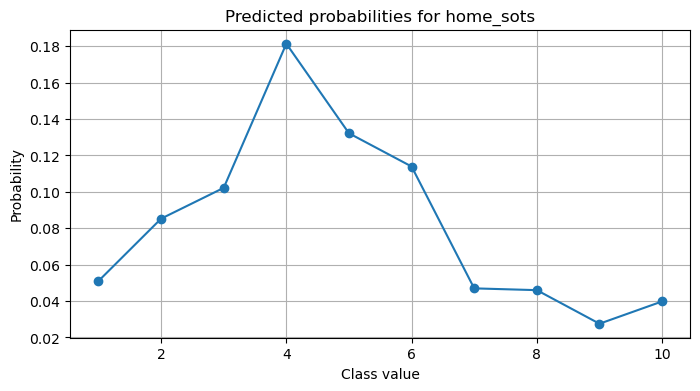

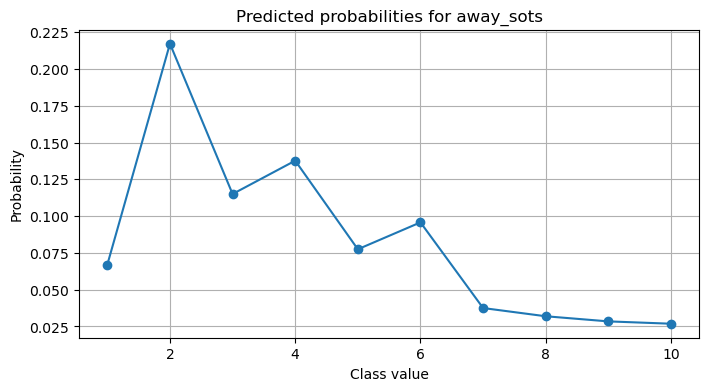

In [37]:
import matplotlib.pyplot as plt

for target, class_probs in predictions.items():
    plt.figure(figsize=(8, 4))
    class_labels = list(class_probs.keys())
    prob_values = [class_probs[c][0] for c in class_labels]
    plt.plot(class_labels, prob_values, marker='o')
    plt.title(f'Predicted probabilities for {target}')
    plt.xlabel('Class value')
    plt.ylabel('Probability')
    plt.grid(True)
    plt.show()